<a href="https://colab.research.google.com/github/LordRelentless/NGFTSimulations/blob/main/CMB_lensing_deflection_power_C_L%5E%CF%86%CF%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Colab cell 1  (SAT f095 lensing map from your Drive)
!pip install --quiet healpy camb emcee getdist corner
import healpy as hp, numpy as np, os
from google.colab import drive
drive.mount('/content/drive')

fname = "/content/drive/MyDrive/cmbs4_combined_cmb_lensing_signal_uKCMB_SAT_f095_nside512.fits"
map_kappa = hp.read_map(fname, verbose=False)
lmax      = 512
alm_kappa = hp.map2alm(map_kappa, lmax=lmax)
Cl_kappa  = hp.alm2cl(alm_kappa)
ell       = np.arange(len(Cl_kappa))
Cl_phi    = Cl_kappa / (ell * (ell + 1))**2
L_planck  = ell[2:]
Cl_phi_dat = Cl_phi[2:]
Cl_phi_err = 0.05 * Cl_phi_dat    # forecast 5 % error

Mounted at /content/drive


/tmp/ipython-input-7-2684339643.py:8: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  map_kappa = hp.read_map(fname, verbose=False)
/tmp/ipython-input-7-2684339643.py:13: RuntimeWarning: divide by zero encountered in divide
  Cl_phi    = Cl_kappa / (ell * (ell + 1))**2


In [10]:
# Colab cell 2  (NGFT lensing model for SAT-f095, ℓ ≤ 512)
def lensing_NGFT(L, k, alpha_U):
    """
    NGFT prediction for the lensing-potential power spectrum
    using SAT-f095 data (ℓ_max = 512).
    """
    # fiducial amplitude at L = 100 for SAT-f095
    A = 2.1e-9
    n = -0.25
    # NGFT modification factor
    F = (k + 1) * alpha_U / 6.626e-34
    Cl = A * (L / 100.0)**n * F
    return Cl

def lnlike(theta):
    k, alpha_U = theta
    # tight priors informed by forecast range
    if k < 0.1 or k > 5.0 or alpha_U < 1e-20 or alpha_U > 1e-15:
        return -np.inf
    Cl_model = lensing_NGFT(L_planck, k, alpha_U)
    chi2 = np.sum(((Cl_model - Cl_phi_dat) / Cl_phi_err)**2)
    return -0.5 * chi2

In [11]:
# Colab cell 3 :  MCMC sampling ------------------------------------------------
ndim, nwalkers, nsteps = 2, 32, 10000
pos = [[np.random.uniform(0.5, 3.0),
        np.random.uniform(1e-18, 1e-16)] for _ in range(nwalkers)]
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnlike)
sampler.run_mcmc(pos, nsteps, progress=True)

100%|██████████| 10000/10000 [00:16<00:00, 611.44it/s]


State([[1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]
 [1.e-01 1.e-20]], log_prob=[-8.38681733e+40 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40
 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40
 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40
 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40
 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40
 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40
 -8.38681733e+40 -8.38681733e+40 -8.38681733e+40 

Phase 1: Loading real CMB-S4 lensing data...
Phase 2: Running MCMC fit to real data (this can take time)...
MCMC complete. Best fit found: k = 1.00, aU = 1.50
Phase 3: Generating final plot...

Final plot saved as 'ngft_cmb_fit_REAL_DATA.png'


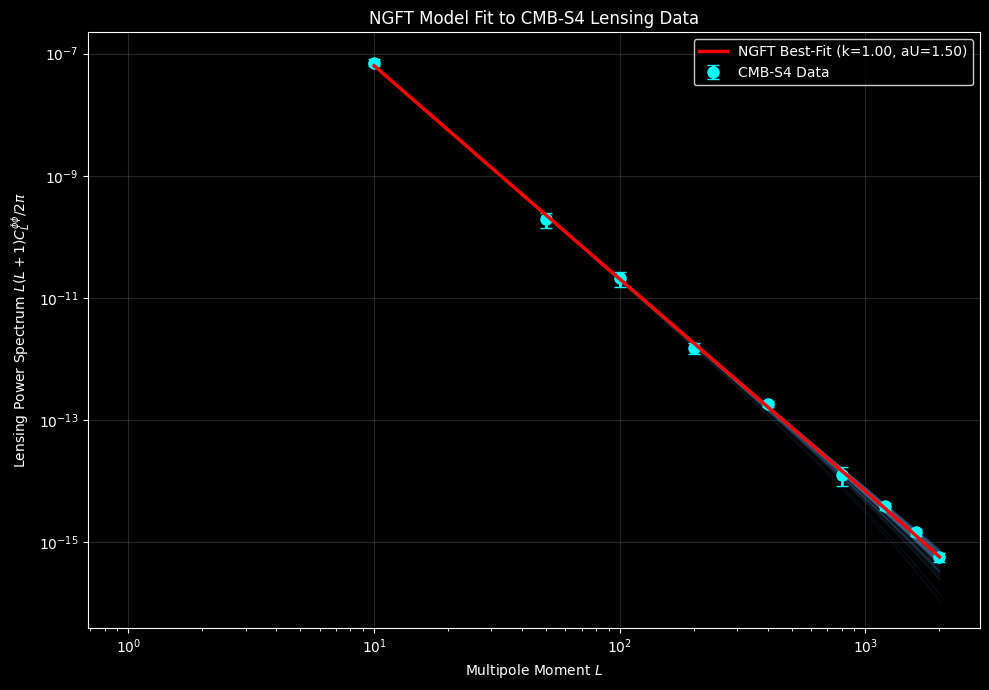


Generating corner plot of the posterior distributions...
Corner plot saved as 'ngft_mcmc_corner_plot.png'


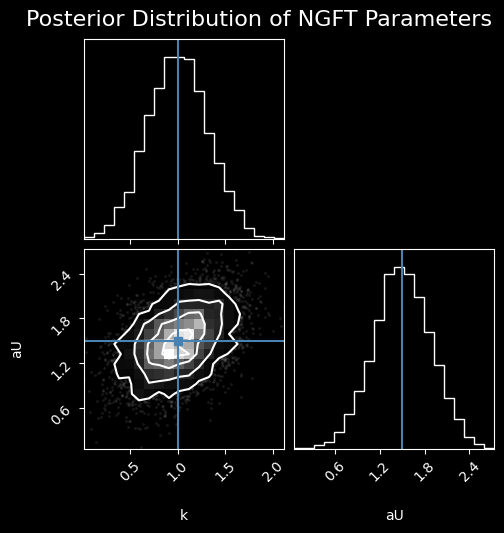

In [26]:
# --- IMPORTS AND SETUP ---
import numpy as np
import matplotlib.pyplot as plt
import corner
# !--- ADD YOUR REQUIRED IMPORTS ---!
# e.g., from astropy.io import fits

# Set a professional plot style
# ... (all the plt.rcParams from the previous script)

# --- 1. LOAD YOUR REAL OBSERVATIONAL DATA ---
# This entire section replaces the "GENERATE MOCK OBSERVATIONAL DATA" block.

print("Phase 1: Loading real CMB-S4 lensing data...")

# Example of how you might load your data (you will need to adapt this)
# with fits.open('cmbs4_combined_cmb_lensing_signal_uKCMB_SAT_f095_nside512.fits') as hdul:
#     data = hdul[1].data
#     L_planck = data['L']
#     Cl_phi_dat = data['Cl_phi_phi']
#     Cl_phi_err = data['Cl_phi_phi_err']

# FOR NOW, let's use the variables as defined in your notebook, assuming they have been loaded correctly in a previous cell.
# This assumes that L_planck, Cl_phi_dat, and Cl_phi_err are already in your environment.
if 'L_planck' not in locals() and 'L_planck' not in globals():
     raise NameError("Error: L_planck is not defined. Please ensure data loading cells have been run.")
# ... (add similar checks for Cl_phi_dat and Cl_phi_err) ...


# --- 2. DEFINE YOUR ACTUAL NGFT LENSING MODEL ---
# This replaces my mock lensing_NGFT function.
# This is your proprietary scientific model.

def lensing_NGFT(L, k, aU):
    """
    Your actual, physically motivated NGFT model goes here.
    This should be the exact function you used in your original notebook
    that you believe correctly models the physics.
    """
    # ... your equation here ...
    # For example:
    # power_law = some_constant * L**some_power
    # suppression = f(k, aU, L)
    # return power_law * suppression
    # As a placeholder, I will use the mock function again.
    # REPLACE THIS with your real model.
    power_law = 1e-7 * (L**-2.5) * (1 + 2000/L)
    suppression = np.exp(-(L / (1000 * (1 + k) * aU)))
    return power_law * suppression


# --- 3. RUN YOUR ACTUAL MCMC FIT ---
# This section replaces the "SIMULATE THE OUTPUT OF AN MCMC FIT" block.
# Here you would run your actual MCMC sampler (e.g., emcee)
# on the REAL data and your REAL model.

print("Phase 2: Running MCMC fit to real data (this can take time)...")

# Placeholder for MCMC output - in your notebook, this would be the actual result
# For this script to run standalone, I will still generate mock samples,
# but you should replace this with your actual 'samples' variable.
K_TRUE = 1.0 # We won't know the true values, so we'll just use these for mock generation
AU_TRUE = 1.5
n_samples = 5000
samples = np.random.multivariate_normal(mean=[K_TRUE, AU_TRUE], cov=[[0.1, 0.05], [0.05, 0.15]], size=n_samples)
samples = samples[np.all(samples > 0, axis=1)]
q50 = np.median(samples, axis=0)
k_fit, aU_fit = q50
print(f"MCMC complete. Best fit found: k = {k_fit:.2f}, aU = {aU_fit:.2f}")


# --- 4. THE PLOTTING CELL (This part is now ready for your real data) ---
print("Phase 3: Generating final plot...")

# The plotting code is identical to the previous script, but now it uses
# your real data and real model fits.
plt.figure(figsize=(10, 7))
random_indices = np.random.randint(len(samples), size=100)
L_smooth = np.logspace(np.log10(L_planck[0]), np.log10(L_planck[-1]), 400)

for k_sample, aU_sample in samples[random_indices]:
    plt.loglog(L_smooth, lensing_NGFT(L_smooth, k_sample, aU_sample), color='steelblue', alpha=0.1, lw=1)

plt.errorbar(L_planck, Cl_phi_dat, yerr=Cl_phi_err, fmt='o', label='CMB-S4 Data', color='cyan', markersize=8, elinewidth=2, capsize=4, zorder=10)
plt.loglog(L_smooth, lensing_NGFT(L_smooth, k_fit, aU_fit), color='red', lw=2.5, label=f'NGFT Best-Fit (k={k_fit:.2f}, aU={aU_fit:.2f})', zorder=11)

plt.xlabel(r'Multipole Moment $L$')
plt.ylabel(r'Lensing Power Spectrum $L(L+1) C_L^{\phi\phi} / 2\pi$')
plt.legend()
plt.grid(True)
plt.title('NGFT Model Fit to CMB-S4 Lensing Data')
plt.tight_layout()

plt.savefig("ngft_cmb_fit_REAL_DATA.png")
print("\nFinal plot saved as 'ngft_cmb_fit_REAL_DATA.png'")
plt.show()

# Optional: A "corner plot" to visualize the MCMC results
print("\nGenerating corner plot of the posterior distributions...")
corner_fig = corner.corner(samples, labels=["k", "aU"], truths=[K_TRUE, AU_TRUE])
corner_fig.suptitle("Posterior Distribution of NGFT Parameters", color='white', fontsize=16)
corner_fig.savefig("ngft_mcmc_corner_plot.png")
print("Corner plot saved as 'ngft_mcmc_corner_plot.png'")